In [1]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, print_raster_stats,gmm_no_manila_path_box_load_all_flood_maps,
    load_all_rainfall_scenarios, get_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps,
    get_raster_stats, load_manila_mask, gmm_path_load_all_flood_maps
)

from data_preprocessing import (normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata )

from flood_maps import (FLOOD_CLASSES, reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps)

from quadrant import ( stack_spatial_inputs, split_into_quadrants, build_train_test_split, extract_spatial_patches, get_quadrant_patch_indices, visualize_quadrant_split )

from vit import ViT

from training import FloodPatchDataset, train_kfold

RANDOM_SEED = 42
NUM_SCENARIO = 50
PATCH_SIZE = 4

In [2]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rainfall_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     466.3908
Mean value:    42.0699
Std dev:       69.0678
Valid pixels:  1,377,000 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.4818
Std dev:       0.9485
Valid pixels:  1,377,000 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.9338
Std dev:       2.5013
Valid pixels:  1,377,000 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

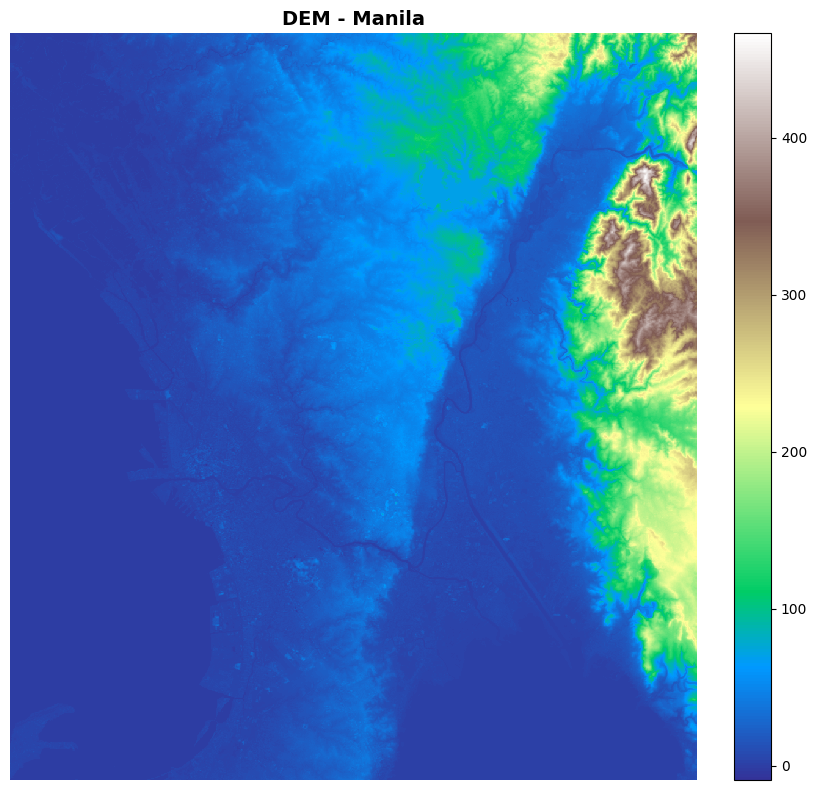

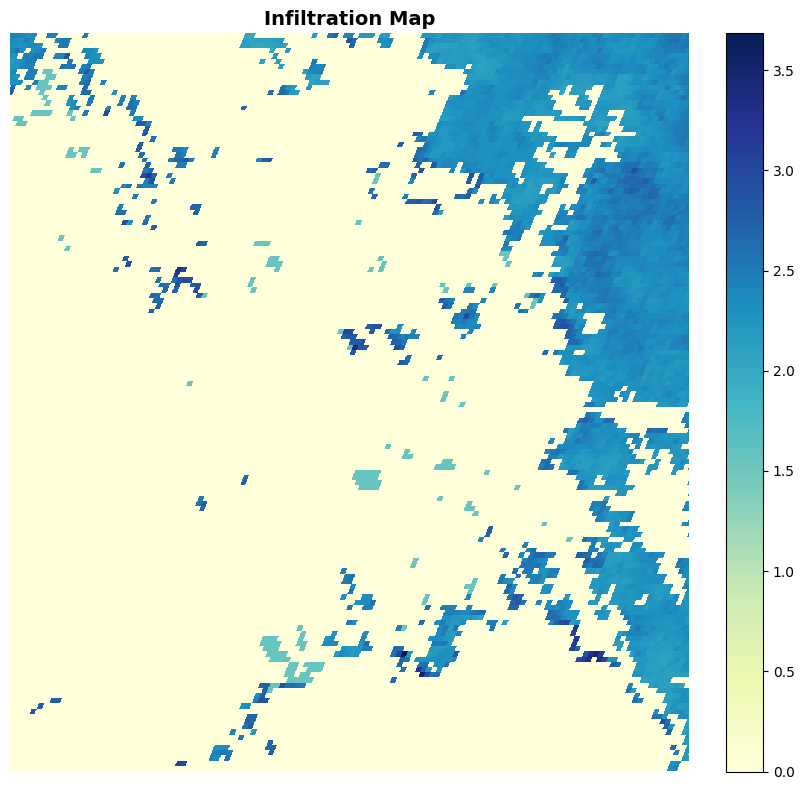

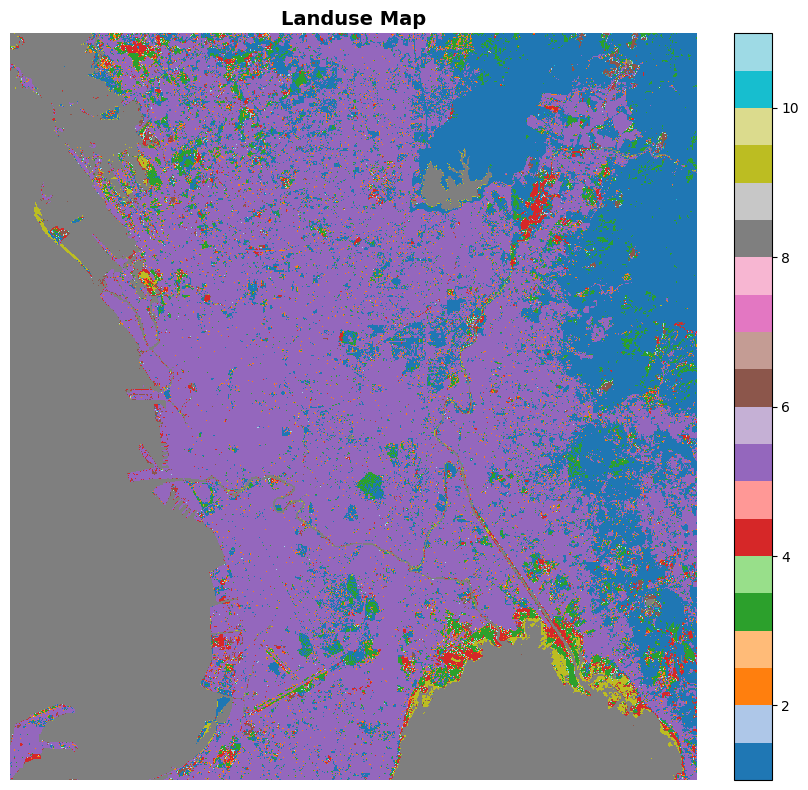

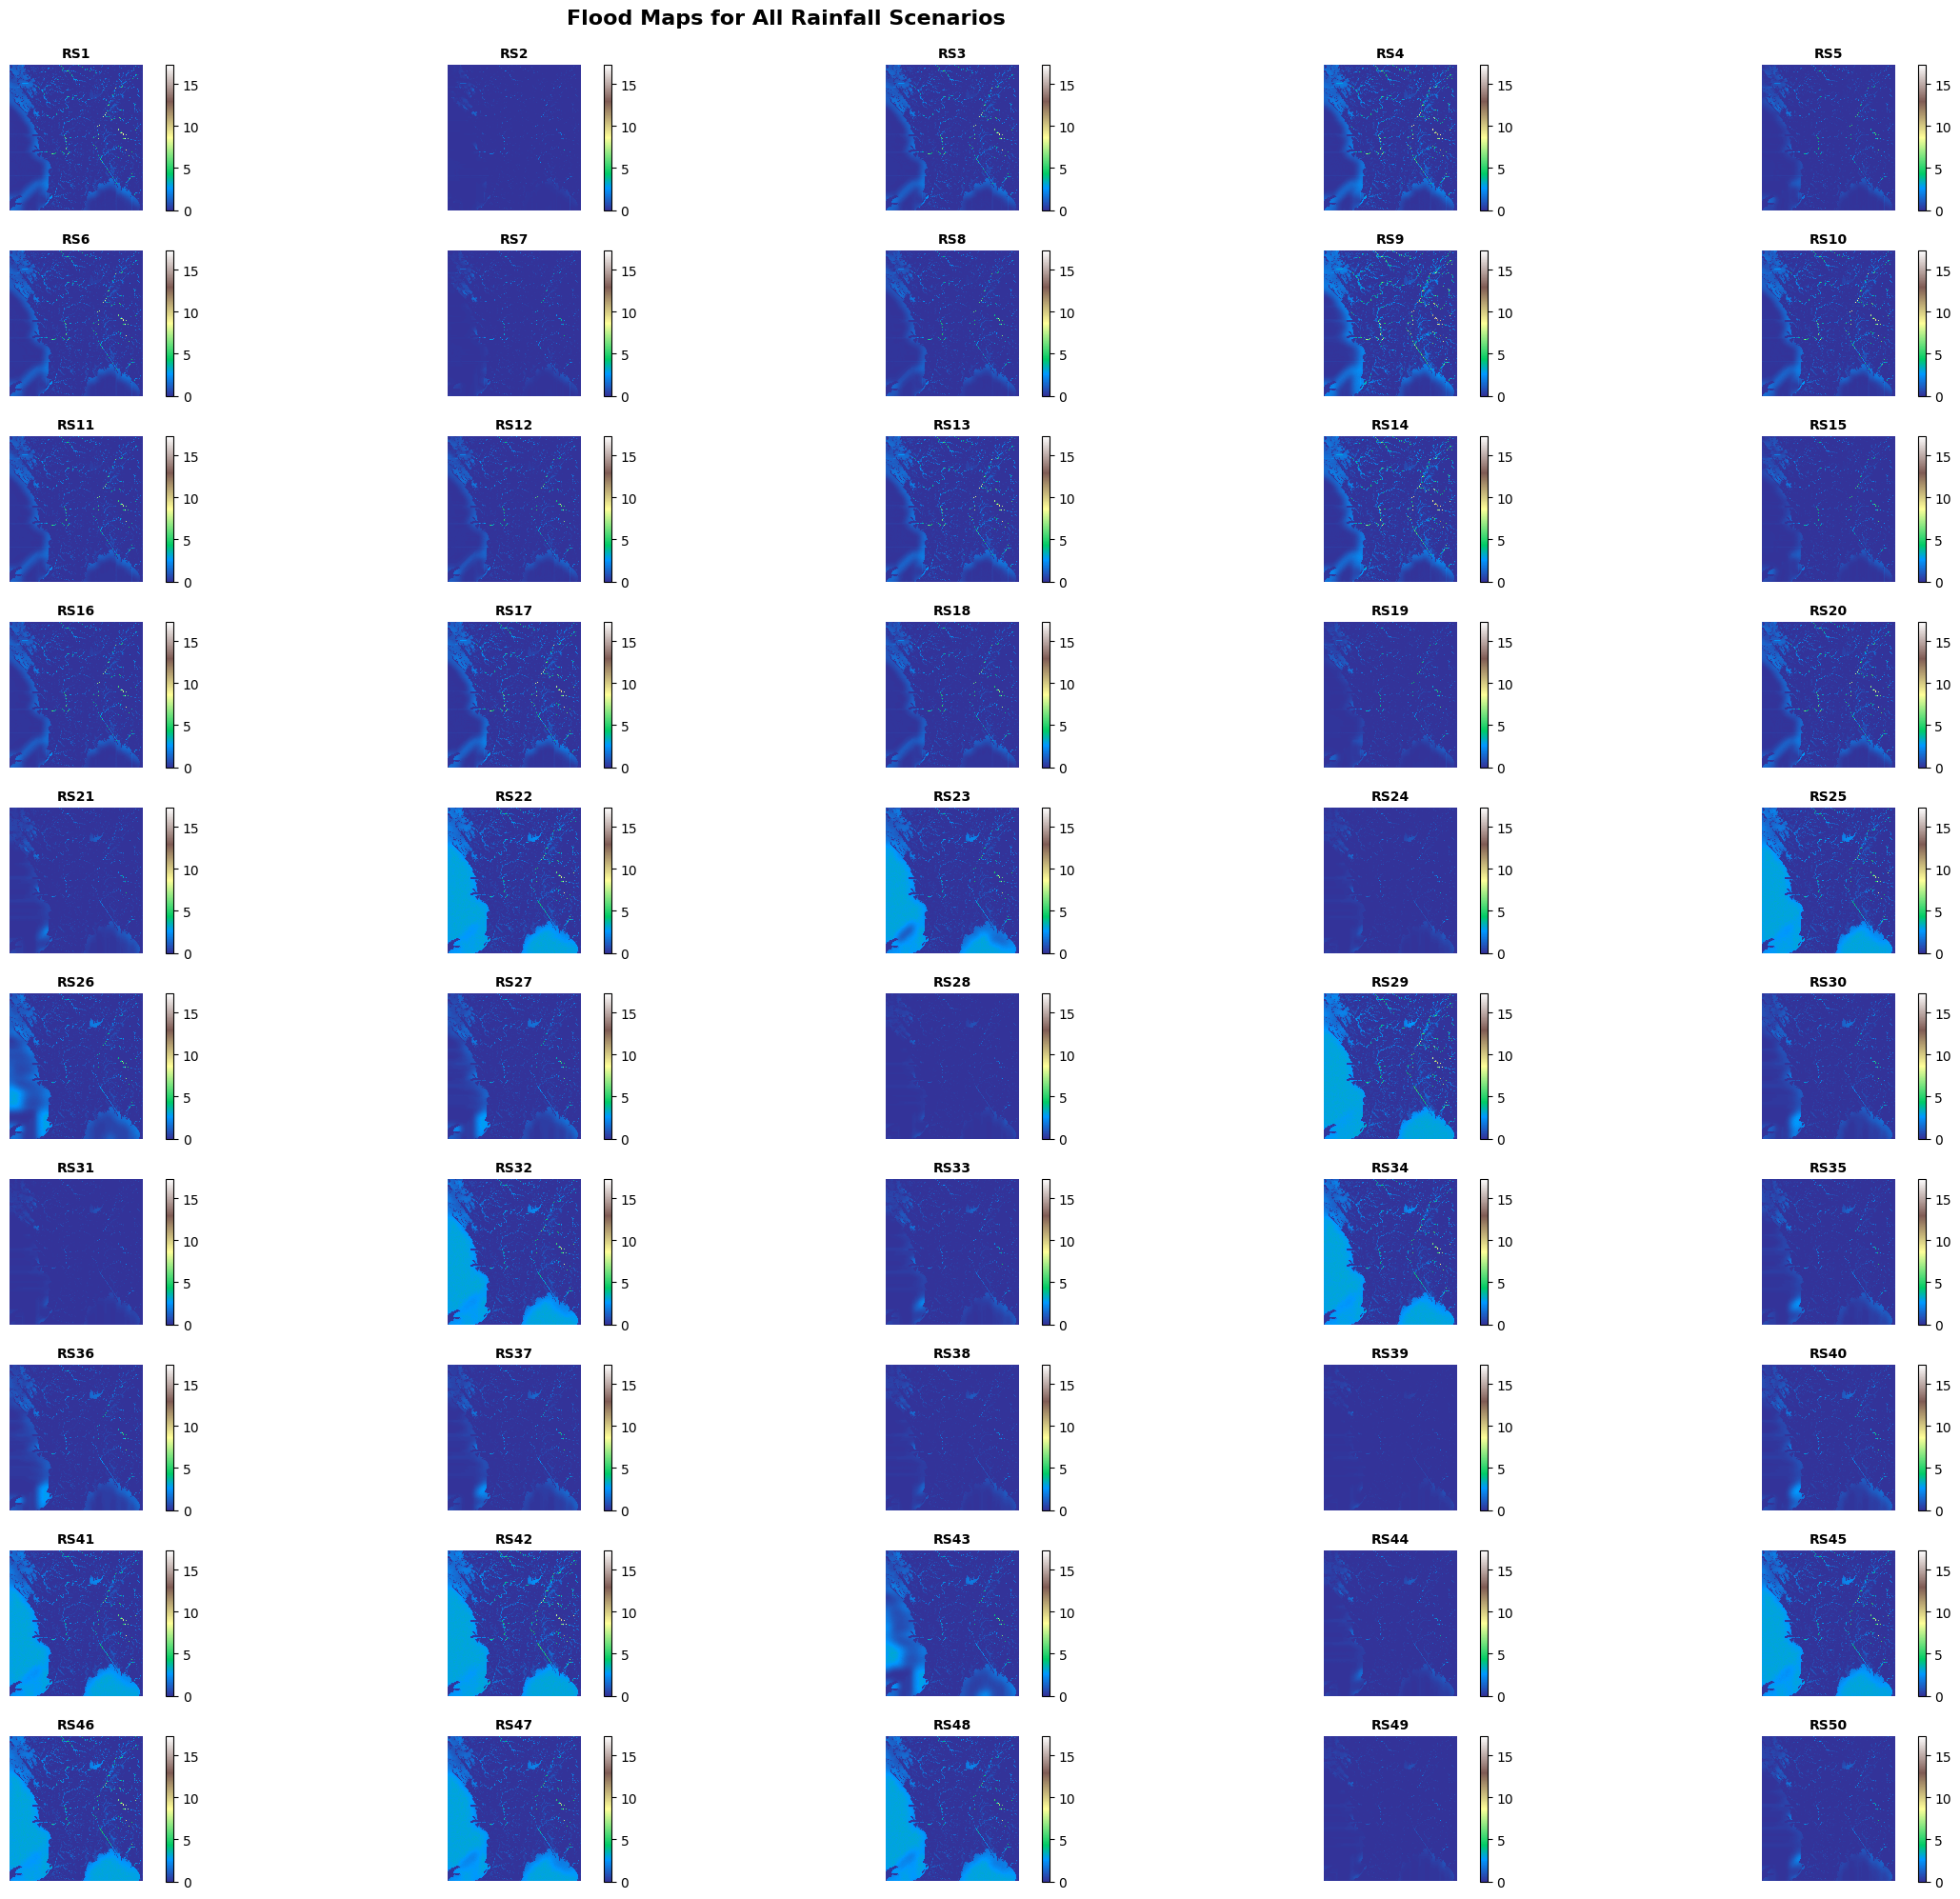

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_path, "greater_mm_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None

fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_path, "GM_Infilt_fixed.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(gmm_path, "GM_LU.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None
    
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_path, "exp-des-4")
flood_maps, flood_metadata = gmm_path_load_all_flood_maps(gmm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

In [4]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rainfall_path)

LOADING RAINFALL SCENARIOS
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps
Rainfall Scenario 5 loaded: 13 time steps
Rainfall Scenario 6 loaded: 13 time steps
Rainfall Scenario 7 loaded: 13 time steps
Rainfall Scenario 8 loaded: 13 time steps
Rainfall Scenario 9 loaded: 13 time steps
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps
Rainfall Scenario 21 loaded: 13 time steps
Rainfall Scenario 22 loaded: 13 time steps
Rainfall Scenario 23 loaded: 13 time

# Data Preprocessing

In [5]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(dem_data, nodata_value=dem_meta.get('nodata'), fill_method='mean')

print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(infilt_data, nodata_value=infilt_meta.get('nodata'), fill_method='mean')

print("\nProcessing Landuse...")
landuse_clean = handle_nodata(landuse_data, nodata_value=landuse_meta.get('nodata'), fill_method='interpolate')


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found


In [6]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_data, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)

# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_data)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)

# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_data, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)



Normalizing DEM...
DEM normalized (min-max): [-9.1316, 466.3908] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1077
Std dev:       0.1452
Valid pixels:  1,377,000 / 1,377,000


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 3.6847] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1308
Std dev:       0.2574
Valid pixels:  1,377,000 / 1,377,000


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.3934
Std dev:       0.2501
Valid pixels:  1,377,000 / 1,377,000



# Flood Maps (Ground Truths)

In [7]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(flood_maps, patch_size=PATCH_SIZE, stride=None, categorization_method='majority', verbose=True)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (85986 patches):
  No Flood    : 64,152 patches (74.61%)
  Light       :  1,892 patches ( 2.20%)
  Moderate    :  3,905 patches ( 4.54%)
  Heavy       :  2,618 patches ( 3.04%)
  Extreme     : 13,419 patches (15.61%)
Scenario  2 (85986 patches):
  No Flood    : 82,402 patches (95.83%)
  Light       :  1,322 patches ( 1.54%)
  Moderate    :  1,553 patches ( 1.81%)
  Heavy       :    364 patches ( 0.42%)
  Extreme     :    345 patches ( 0.40%)
Scenario  3 (85986 patches):
  No Flood    : 64,911 patches (75.49%)
  Light       :  1,993 patches ( 2.32%)
  Moderate    :  3,906 patches ( 4.54%)
  Heavy       :  2,737 patches ( 3.18%)
  Ex

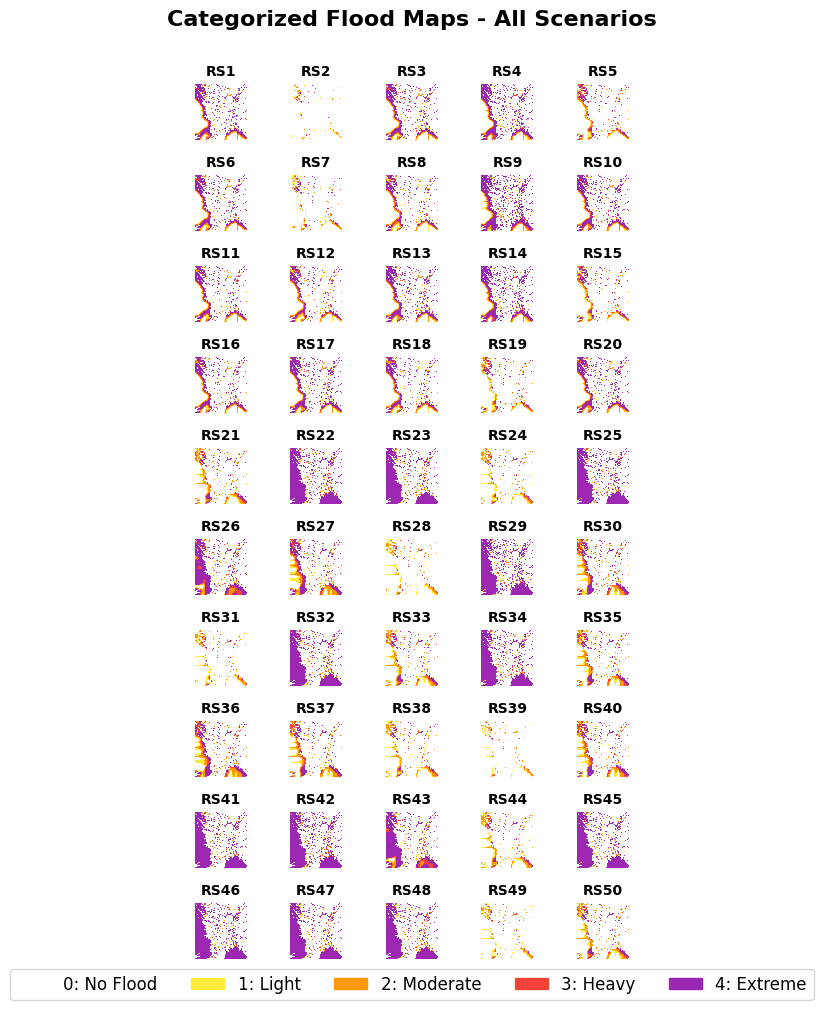

In [8]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)
fig_all = visualize_all_categorized_maps(reconstructed_maps, scenario_ids=list(range(1, 51)), figsize=(5, 10), ncols=5)
plt.show()

In [9]:
display(flood_maps_categorized_patch)

[array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([1, 1, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], dtype=int8),
 array([4,

# Rainfall

In [10]:
import numpy as np
import pandas as pd
from typing import Dict, Any, List

# ── Storm Type Registry ───────────────────────────────────────────────────────
NUM_STORM_TYPES = 4
STORM_TYPE_MAP = {
    1: "SCS Front-loaded",
    2: "SCS Balanced",
    3: "SCS Back-loaded",
    4: "Triangular",
}

def _infer_type_id_from_sid(sid: int) -> int:
    """Infer storm type directly from scenario ID (fixed dataset design)."""
    if   1  <= sid <= 10: return 1
    elif 11 <= sid <= 20: return 2
    elif 21 <= sid <= 30: return 3
    elif 31 <= sid <= 50: return 4
    else:
        raise ValueError(f"Scenario ID {sid} out of expected range 1–50")

# ── Loader ────────────────────────────────────────────────────────────────────
def load_scenario_metadata(info_csv_path: str) -> Dict[int, Dict[str, Any]]:
    df = pd.read_csv(info_csv_path)

    required = {
        "No",
        "Pattern Type",
        "Total storm depth P (mm)",
        "Peak time fraction r (tpeak / D)",
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"info.csv missing columns: {missing}")

    metadata = {}

    for _, row in df.iterrows():
        sid = int(row["No"])
        type_id = _infer_type_id_from_sid(sid)

        # r = 0.0 for SCS types; actual value for triangular
        if type_id in (1, 2, 3):
            r = 0.0
        else:
            r = float(row["Peak time fraction r (tpeak / D)"])

        metadata[sid] = {
            "type_id": type_id,
            "label": STORM_TYPE_MAP[type_id],
            "pattern_type": row["Pattern Type"],
            "total_depth_mm": float(row["Total storm depth P (mm)"]),
            "r": r,
        }

    print(f"Loaded {len(metadata)} scenarios from {info_csv_path}")
    return metadata

# ── One-Hot Encoding ──────────────────────────────────────────────────────────
def get_storm_type_onehot(sid: int, scenario_metadata: Dict[int, Dict[str, Any]]) -> np.ndarray:
    """Return (4,) one-hot vector for storm type."""
    type_id = scenario_metadata[sid]["type_id"]
    onehot = np.zeros(NUM_STORM_TYPES, dtype=np.float32)
    onehot[type_id - 1] = 1.0
    return onehot

def build_all_storm_onehots(scenario_metadata: Dict[int, Dict[str, Any]]) -> np.ndarray:
    """Return (N_scenarios, 4) one-hot matrix."""
    sids = sorted(scenario_metadata.keys())
    onehots = np.stack(
        [get_storm_type_onehot(sid, scenario_metadata) for sid in sids],
        axis=0
    )

    print(f"Storm one-hot matrix shape: {onehots.shape}")
    return onehots

# ── Conditioning Vector ───────────────────────────────────────────────────────
# rain(13) + onehot(4) + r(1) + depth_norm(1) = 19 dims
CONDITIONING_DIM = 19

def build_conditioning_vector(
    rain_normalized: np.ndarray,  # (13,)
    type_id: int,                 # 1
    r: float,                     # 0.0
    total_depth_mm: float,        # 38.0
    depth_min: float,             # 5.0
    depth_max: float,             # 78.0
) -> np.ndarray:
    """Build full (19,) conditioning vector."""

    # Step 1: Create one-hot for storm type
    onehot = np.zeros(4, dtype=np.float32)
    onehot[type_id - 1] = 1.0  # type_id=1 → onehot[0]=1.0
    # Result: [1.0, 0.0, 0.0, 0.0]

    # Step 2: Normalize depth to [0, 1]
    depth_norm = (total_depth_mm - depth_min) / (depth_max - depth_min)

    # Step 3: Concatenate all 19 dimensions
    return np.concatenate([
        rain_normalized.astype(np.float32),   # (13,) rainfall
        onehot,                               # (4,) storm type one-hot
        [np.float32(r)],                      # (1,) r parameter → [0.0]
        [np.float32(depth_norm)],             # (1,) normalized depth → [0.452]
    ])
    # Result: (19,) vector


def build_all_conditioning_vectors(
    rain_embeddings: np.ndarray,  # (50, 13) — normalized rainfall sequences
    scenario_metadata: Dict[int, Dict[str, Any]],  # 50 scenarios' metadata
    depth_min: float,             # Min depth from training (5.0 mm)
    depth_max: float,             # Max depth from training (78.0 mm)
) -> np.ndarray:                  # Returns (50, 19) — full conditioning vectors
    """Build (N_scenarios, 19) conditioning matrix."""

    sids = sorted(scenario_metadata.keys())  # [1, 2, 3, ..., 50]
    vectors = []

    for i, sid in enumerate(sids):
        m = scenario_metadata[sid]  # Get metadata for this scenario

        vec = build_conditioning_vector(
            rain_normalized=rain_embeddings[i],      # (13,) rainfall for scenario i
            type_id=m["type_id"],                    # 1, 2, 3, or 4 (storm type)
            r=m["r"],                                # 0.0 for SCS, tpeak for triangular
            total_depth_mm=m["total_depth_mm"],      # Actual depth (mm)
            depth_min=depth_min,                     # 5.0
            depth_max=depth_max,                     # 78.0
        )

        vectors.append(vec)

    out = np.stack(vectors, axis=0)  # Stack all 50 vectors → (50, 19)

    print(f"Conditioning matrix shape: {out.shape}")
    return out


# ── Validation ────────────────────────────────────────────────────────────────
def validate_and_print_metadata(
    scenario_metadata: Dict[int, Dict[str, Any]],
    train_ids: List[int],
    test_ids: List[int],
) -> None:

    print("\n" + "=" * 70)
    print("SCENARIO METADATA SUMMARY")
    print("=" * 70)

    all_ids = sorted(scenario_metadata.keys())
    print(f"\nTotal scenarios: {len(all_ids)}")

    # Full dataset distribution
    print("\nStorm type distribution (full dataset):")

    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid, m in scenario_metadata.items()
               if m["type_id"] == tid]

        if not ids:
            continue

        depths = [scenario_metadata[sid]["total_depth_mm"] for sid in ids]

        print(f"  Type {tid} - {label:<18}: "
              f"{len(ids):>2} scenarios  "
              f"(IDs {min(ids)}–{max(ids)})  "
              f"depth {min(depths):.0f}–{max(depths):.0f} mm")

    # Train distribution
    print("\nTrain set distribution:")
    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid in train_ids
               if scenario_metadata[sid]["type_id"] == tid]
        print(f"  Type {tid} - {label:<18}: {len(ids)}")

    # Test distribution
    print("\nTest set distribution:")
    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid in test_ids
               if scenario_metadata[sid]["type_id"] == tid]
        print(f"  Type {tid} - {label:<18}: {len(ids)}")

    # Triangular r range
    triangular = [
        m["r"] for m in scenario_metadata.values()
        if m["type_id"] == 4
    ]

    if triangular:
        print(f"\nTriangular r range: "
              f"{min(triangular):.2f} – {max(triangular):.2f}")

    print("=" * 70)

In [11]:
scenario_metadata = load_scenario_metadata(os.path.join(repo_root, "info.csv"))
validate_and_print_metadata(scenario_metadata, 
                             list(range(1, NUM_SCENARIO+1)),
                             list(range(1, NUM_SCENARIO+1)))

# ── Depth normalization stats (from training data) ────────────────────────────
all_depths = [m['total_depth_mm'] for m in scenario_metadata.values()]
depth_min, depth_max = min(all_depths), max(all_depths)
print(f"Depth range: {depth_min:.1f} – {depth_max:.1f} mm")


Loaded 50 scenarios from f:\ManilaFloodingThesisGroup\th3-experiments\info.csv

SCENARIO METADATA SUMMARY

Total scenarios: 50

Storm type distribution (full dataset):
  Type 1 - SCS Front-loaded  : 10 scenarios  (IDs 1–10)  depth 6–78 mm
  Type 2 - SCS Balanced      : 10 scenarios  (IDs 11–20)  depth 19–78 mm
  Type 3 - SCS Back-loaded   : 10 scenarios  (IDs 21–30)  depth 7–75 mm
  Type 4 - Triangular        : 20 scenarios  (IDs 31–50)  depth 5–77 mm

Train set distribution:
  Type 1 - SCS Front-loaded  : 10
  Type 2 - SCS Balanced      : 10
  Type 3 - SCS Back-loaded   : 10
  Type 4 - Triangular        : 20

Test set distribution:
  Type 1 - SCS Front-loaded  : 10
  Type 2 - SCS Balanced      : 10
  Type 3 - SCS Back-loaded   : 10
  Type 4 - Triangular        : 20

Triangular r range: 0.10 – 0.90
Depth range: 5.0 – 78.0 mm


In [12]:
print(scenario_metadata)

{1: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 38.0, 'r': 0.0}, 2: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 6.0, 'r': 0.0}, 3: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 34.0, 'r': 0.0}, 4: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 54.0, 'r': 0.0}, 5: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 17.0, 'r': 0.0}, 6: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 33.0, 'r': 0.0}, 7: {'type_id': 1, 'lab

# Data Splitting Strategy

In [13]:
print("Stack Spatial Inputs")
spatial_stack = stack_spatial_inputs(dem_normalized, infilt_normalized, landuse_normalized)

print("Flood maps already categorized →", len(flood_maps_categorized_patch), "scenarios")

print("Quadrant Split — Spatial Stack")
spatial_quadrants = split_into_quadrants(spatial_stack)

print("\nExtract Spatial Patches (full map)")
spatial_patches = extract_spatial_patches(spatial_stack, patch_size=PATCH_SIZE)

print("\nCompute Quadrant Patch Indices")
H, W = dem_normalized.shape
quadrant_indices = get_quadrant_patch_indices(H, W, patch_size=PATCH_SIZE)

print("\nBuild Train / Test Split")
dataset = build_train_test_split(spatial_patches, flood_maps_categorized_patch, quadrant_indices, rainfall_scenarios=rainfall_scenarios,)

Stack Spatial Inputs
[Stack] Spatial input shape: (1224, 1125, 3)  |  Channels: DEM, Infiltration, Landuse
Flood maps already categorized → 50 scenarios
Quadrant Split — Spatial Stack
  [Q1 | TRAIN] shape: (612, 562, 3)
  [Q2 | TRAIN] shape: (612, 562, 3)
  [Q3 | TEST] shape: (612, 562, 3)
  [Q4 | TRAIN] shape: (612, 562, 3)

Extract Spatial Patches (full map)
  Spatial patches extracted: 85,986  shape: (85986, 4, 4, 3)

Compute Quadrant Patch Indices
  [Q1 | TRAIN] 21,420 patches
  [Q2 | TRAIN] 21,573 patches
  [Q3 | TEST] 21,420 patches
  [Q4 | TRAIN] 21,573 patches

Build Train / Test Split

QUADRANT SPLIT SUMMARY
  Train quadrants  : ['Q1', 'Q2', 'Q4']
  Test  quadrants  : ['Q3']
  X_train          : (64566, 4, 4, 3)  (patches, h, w, C)
  X_test           : (21420, 4, 4, 3)   (patches, h, w, C)
  y_train          : (50, 64566)  (scenarios, patches)  — int8 class
  y_test           : (50, 21420)   (scenarios, patches)  — int8 class
  Rainfall         : 50 scenarios (NOT split spatia

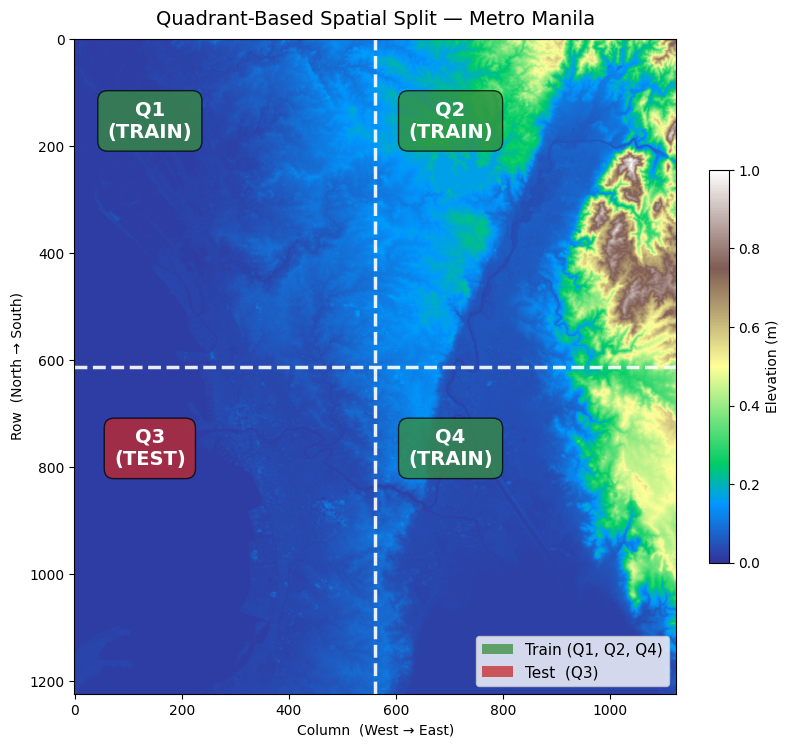

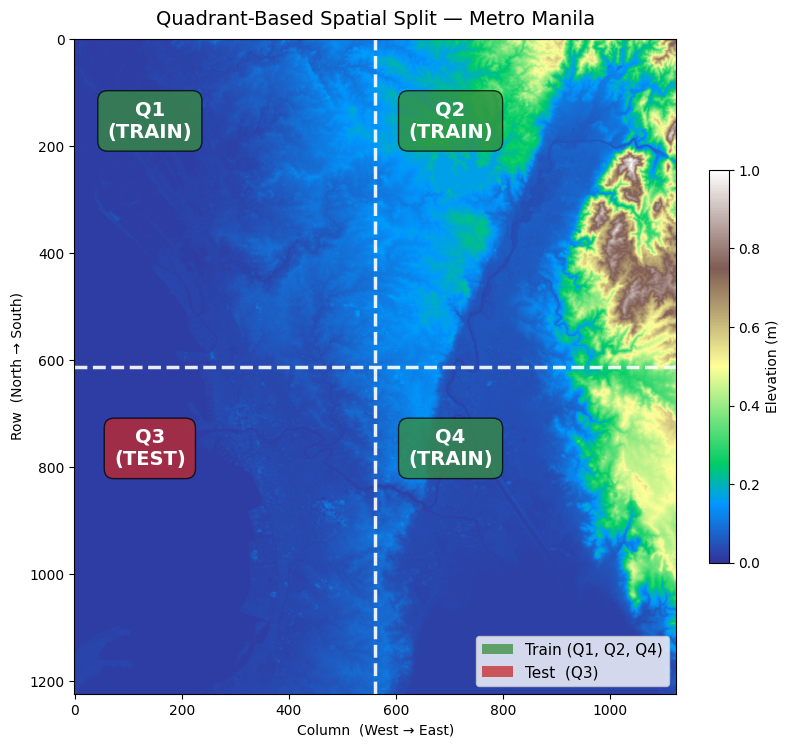

In [14]:
visualize_quadrant_split(dem_normalized)

# Rainfall Encoding

In [15]:
all_intensities = np.concatenate([df['intensity_mmhr'].values for df in rainfall_scenarios])
rain_min, rain_max = all_intensities.min(), all_intensities.max()

def normalize_rainfall_scenarios(rainfall_scenarios, rain_min, rain_max):
    normalized = []
    for df in rainfall_scenarios:
        intensity = (df['intensity_mmhr'].values - rain_min) / (rain_max - rain_min)
        normalized.append(intensity.astype(np.float32))
    return np.stack(normalized, axis=0) 

rain_embeddings = normalize_rainfall_scenarios(rainfall_scenarios, rain_min, rain_max)
print(rain_embeddings.shape) 

(50, 13)


In [16]:
# ── Build conditioning vectors (19-dim) ───────────────────────────────────────
# rain_embeddings shape: (50, 13) — already built
conditioning_vectors = build_all_conditioning_vectors(
    rain_embeddings   = rain_embeddings,      # (50, 13)
    scenario_metadata = scenario_metadata,
    depth_min         = depth_min,
    depth_max         = depth_max,
)   # → (50, 19)


Conditioning matrix shape: (50, 19)


In [17]:
print("\nConditioning vector breakdown (dims):")
print("  [0 :13] = normalized rainfall sequence")
print("  [13:17] = storm type one-hot")
print("  [17]    = r  (tpeak fraction)")
print("  [18]    = normalized total depth")

for sid in [1, 11, 21, 31, 40]:
    v = conditioning_vectors[sid - 1]
    print(f"\n  RS{sid:>2} ({scenario_metadata[sid]['label']:<18})"
          f"  rain[:3]={v[:3].round(3)}"
          f"  onehot={v[13:17].astype(int)}"
          f"  r={v[17]:.2f}"
          f"  depth_norm={v[18]:.3f}")


Conditioning vector breakdown (dims):
  [0 :13] = normalized rainfall sequence
  [13:17] = storm type one-hot
  [17]    = r  (tpeak fraction)
  [18]    = normalized total depth

  RS 1 (SCS Front-loaded  )  rain[:3]=[0.209 0.436 0.487]  onehot=[1 0 0 0]  r=0.00  depth_norm=0.452

  RS11 (SCS Balanced      )  rain[:3]=[0.02  0.09  0.168]  onehot=[0 1 0 0]  r=0.00  depth_norm=0.411

  RS21 (SCS Back-loaded   )  rain[:3]=[0.    0.    0.003]  onehot=[0 0 1 0]  r=0.00  depth_norm=0.123

  RS31 (Triangular        )  rain[:3]=[0.016 0.031 0.047]  onehot=[0 0 0 1]  r=0.40  depth_norm=0.041

  RS40 (Triangular        )  rain[:3]=[0.039 0.078 0.117]  onehot=[0 0 0 1]  r=0.40  depth_norm=0.205


# ViT Config

In [18]:
from config import Config
from model_config import model_factory, make_model
from training import FloodPatchDataset, train_kfold

cfg = Config()  
cfg.save(cfg.train.output_dir / 'config.json')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = FloodPatchDataset(
    X_spatial = dataset['X_train'],
    y_labels  = dataset['y_train'],
    rainfall  = conditioning_vectors,
)

[FloodPatchDataset]
  Spatial tokens : torch.Size([64566, 3, 4, 4])  (N_patches, C, H, W)
  Labels         : torch.Size([64566, 50])  (N_patches, N_scenarios)
  Rainfall       : torch.Size([50, 19])  (N_scenarios, timesteps)
  Total samples  : 3,228,300  (patches × scenarios)


# Training Setup

In [19]:
# ── K-Fold Training ─────────────────────────────────────────────────────
fold_histories, best_fold = train_kfold(
    model_factory = model_factory(cfg.model),
    full_dataset  = train_dataset,
    y_train       = dataset['y_train'],
    cfg           = cfg.train,
    device        = device,
)


FOLD 1 / 2
  Train samples : 1,614,150
  Val   samples : 1,614,150
    [TRAIN] batch  1000/6306  loss=1.5355  acc=0.4660
    [TRAIN] batch  2000/6306  loss=1.5355  acc=0.4658
    [TRAIN] batch  3000/6306  loss=1.5354  acc=0.4658
    [TRAIN] batch  4000/6306  loss=1.5354  acc=0.4656
    [TRAIN] batch  5000/6306  loss=1.5353  acc=0.4658
    [TRAIN] batch  6000/6306  loss=1.5354  acc=0.4660
    [TRAIN] batch  6306/6306  loss=1.5354  acc=0.4659
    [VAL  ] batch  1000/6306  loss=1.5354  acc=0.5245
    [VAL  ] batch  2000/6306  loss=1.5353  acc=0.5247
    [VAL  ] batch  3000/6306  loss=1.5351  acc=0.5248
    [VAL  ] batch  4000/6306  loss=1.5352  acc=0.5244
    [VAL  ] batch  5000/6306  loss=1.5352  acc=0.5246
    [VAL  ] batch  6000/6306  loss=1.5351  acc=0.5244
    [VAL  ] batch  6306/6306  loss=1.5351  acc=0.5245
  Epoch  1/20  lr=0.000000  train_loss=1.5354  train_acc=0.4659  val_loss=1.5351  val_acc=0.5245  val_f1=0.1486
  → Best Macro F1: 0.1486
    [TRAIN] batch  1000/6306  loss=1.2

In [20]:
# Loading best model
ckpt = torch.load(cfg.train.output_dir / f'fold_{best_fold+1}' / 'best_model.pt', map_location=device)
model = make_model(cfg.model)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()

print(f"✓ Loaded fold {best_fold+1}")
print(f"  Best macro F1: {ckpt.get('best_macro_f1', 'N/A')}")

✓ Loaded fold 2
  Best macro F1: 0.4165907845680539


# Testing

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from testing import ( prepare_ground_truth, evaluate_all_scenarios, plot_metrics_summary, plot_per_scenario_metrics,plot_per_class_metrics, plot_flood_on_dem )

print("\nPreparing ground truth maps for test scenarios...")
ground_truth = prepare_ground_truth(
    y_test           = dataset['y_test'],     
    quadrant_indices = quadrant_indices,
    patch_metadata   = patch_metadata[0],
)


Preparing ground truth maps for test scenarios...

Preparing ground truth maps for test scenarios...
  Q3 patch grid : 153 rows × 140 cols = 21420 patches
  GT maps shape : (50, 153, 140)  ✓


In [34]:
print("\nEvaluating all test scenarios...")
results = evaluate_all_scenarios(
    model           = model,
    X_test          = dataset['X_test'],
    y_test          = dataset['y_test'],
    conditioning_vectors = conditioning_vectors,
    ground_truth    = ground_truth,
    batch_size      = cfg.train.batch_size,
    device          = device,
    num_classes     = cfg.model.num_classes,
)


Evaluating all test scenarios...

Evaluating all test scenarios...
  RS01  Acc=0.5083  Prec=0.2602  Rec=0.2844  F1=0.2251  IoU=0.1567  Conf=0.573  Uncertain=64.7%
  RS02  Acc=0.4655  Prec=0.2101  Rec=0.2743  F1=0.1404  IoU=0.1001  Conf=0.685  Uncertain=52.6%
  RS03  Acc=0.5099  Prec=0.2556  Rec=0.2865  F1=0.2220  IoU=0.1557  Conf=0.573  Uncertain=62.0%
  RS04  Acc=0.4967  Prec=0.2661  Rec=0.2801  F1=0.2338  IoU=0.1592  Conf=0.556  Uncertain=20.5%
  RS05  Acc=0.4642  Prec=0.2449  Rec=0.2936  F1=0.1807  IoU=0.1272  Conf=0.584  Uncertain=53.2%
  RS06  Acc=0.5105  Prec=0.2566  Rec=0.2876  F1=0.2219  IoU=0.1558  Conf=0.572  Uncertain=61.2%
  RS07  Acc=0.4826  Prec=0.2495  Rec=0.3000  F1=0.1846  IoU=0.1250  Conf=0.663  Uncertain=53.0%
  RS08  Acc=0.4685  Prec=0.2582  Rec=0.3071  F1=0.1965  IoU=0.1394  Conf=0.593  Uncertain=54.0%
  RS09  Acc=0.4736  Prec=0.2778  Rec=0.2717  F1=0.2396  IoU=0.1614  Conf=0.514  Uncertain=27.4%
  RS10  Acc=0.5083  Prec=0.2615  Rec=0.2838  F1=0.2272  IoU=0.1576  


Generating visualizations...


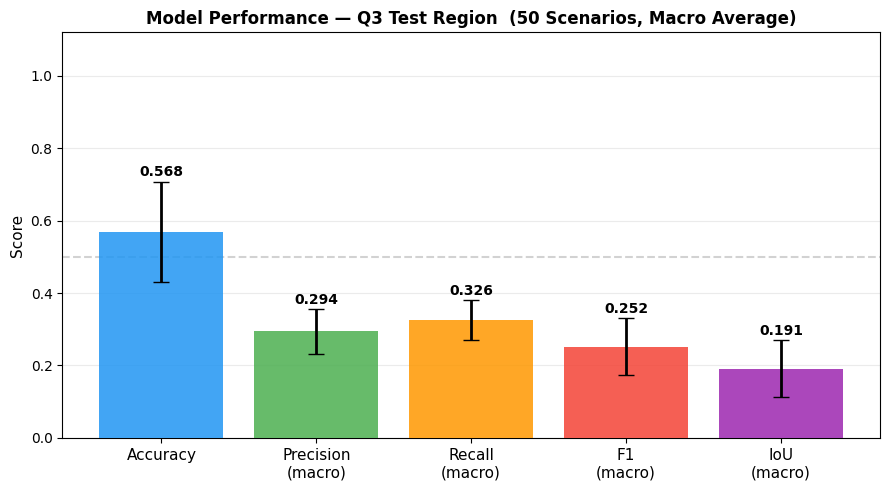

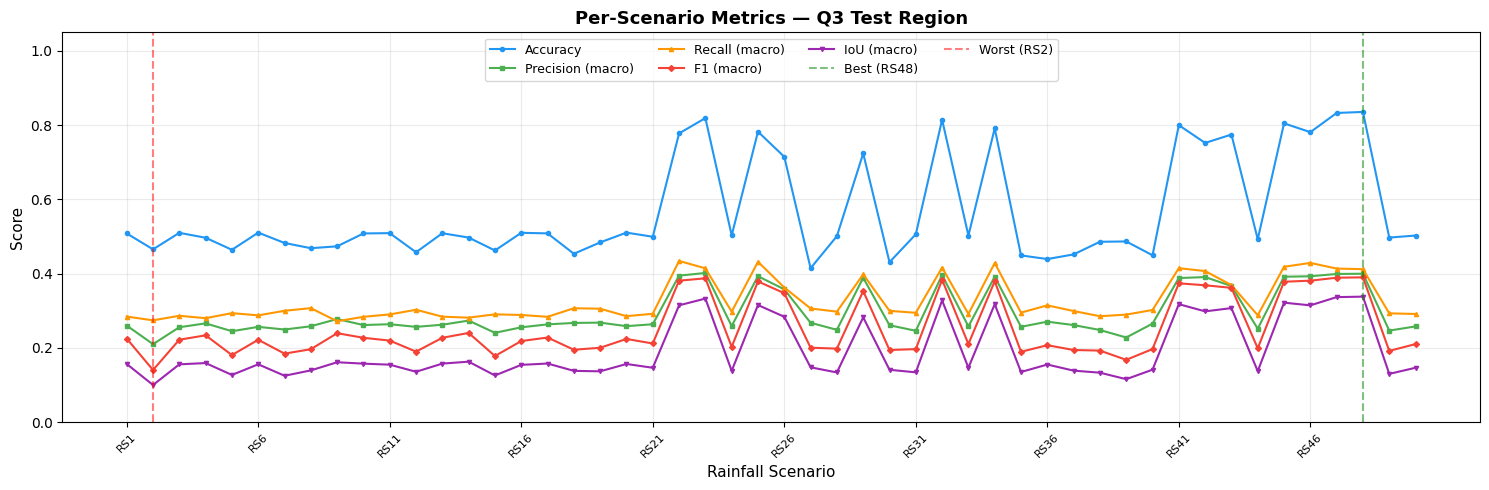

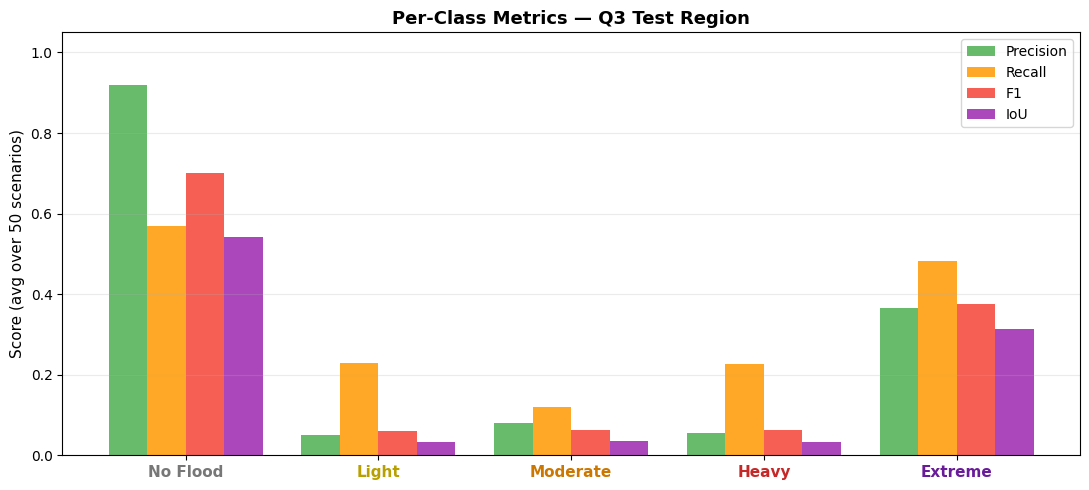

In [35]:
print("\nGenerating visualizations...")

fig1 = plot_metrics_summary(results)
fig1.savefig("eval_metrics_summary.png", dpi=150, bbox_inches='tight')

fig2 = plot_per_scenario_metrics(results)
fig2.savefig("eval_per_scenario.png", dpi=150, bbox_inches='tight')

fig3 = plot_per_class_metrics(results)
fig3.savefig("eval_per_class.png", dpi=150, bbox_inches='tight')

plt.show()

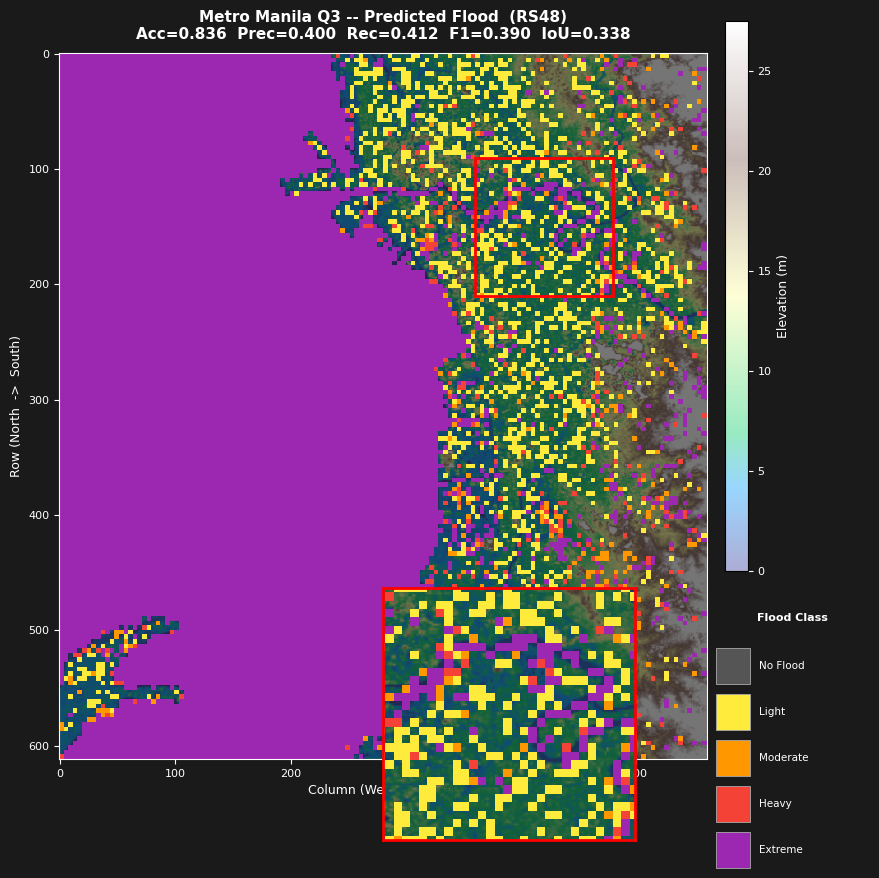

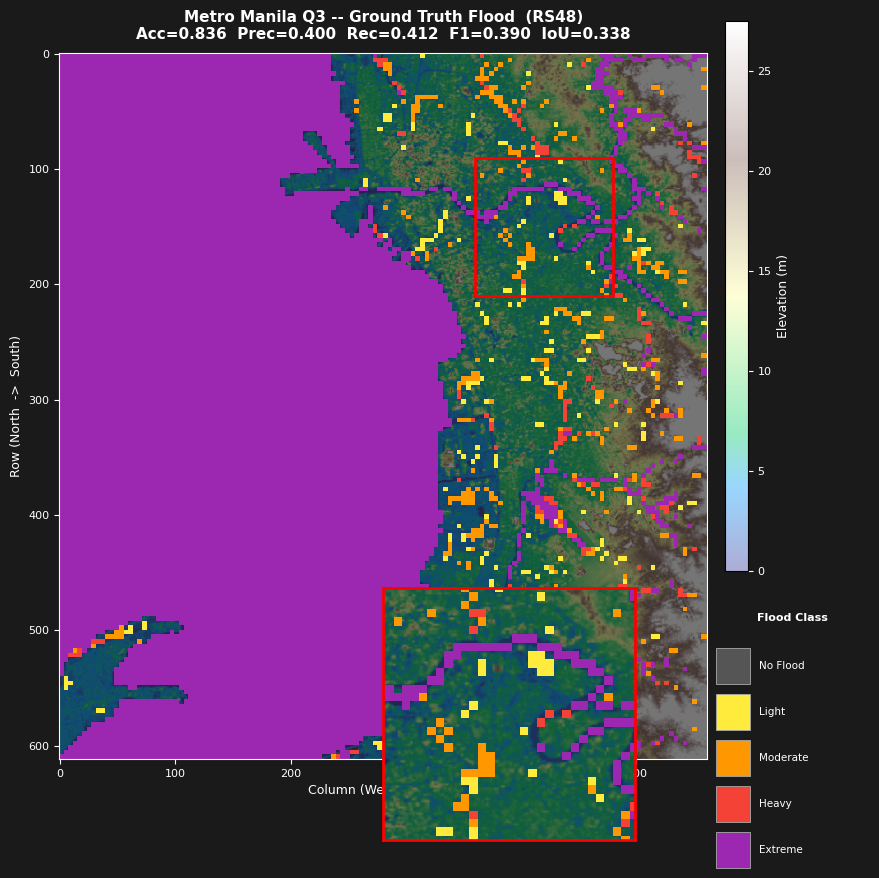


All figures saved.
  Best  scenario: RS48
  Worst scenario: RS2


In [36]:
H_dem, W_dem = dem_clean.shape
dem_q3 = dem_clean[H_dem//2:, :W_dem//2]   

best_idx  = results['aggregate']['best_scenario']  - 1
worst_idx = results['aggregate']['worst_scenario'] - 1

# Single scenario — predicted
fig4 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig4.savefig("eval_dem_best_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig5 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig5.savefig("eval_dem_best_gt.png", dpi=150, bbox_inches='tight')

plt.show()
print("\nAll figures saved.")
print(f"  Best  scenario: RS{results['aggregate']['best_scenario']}")
print(f"  Worst scenario: RS{results['aggregate']['worst_scenario']}")

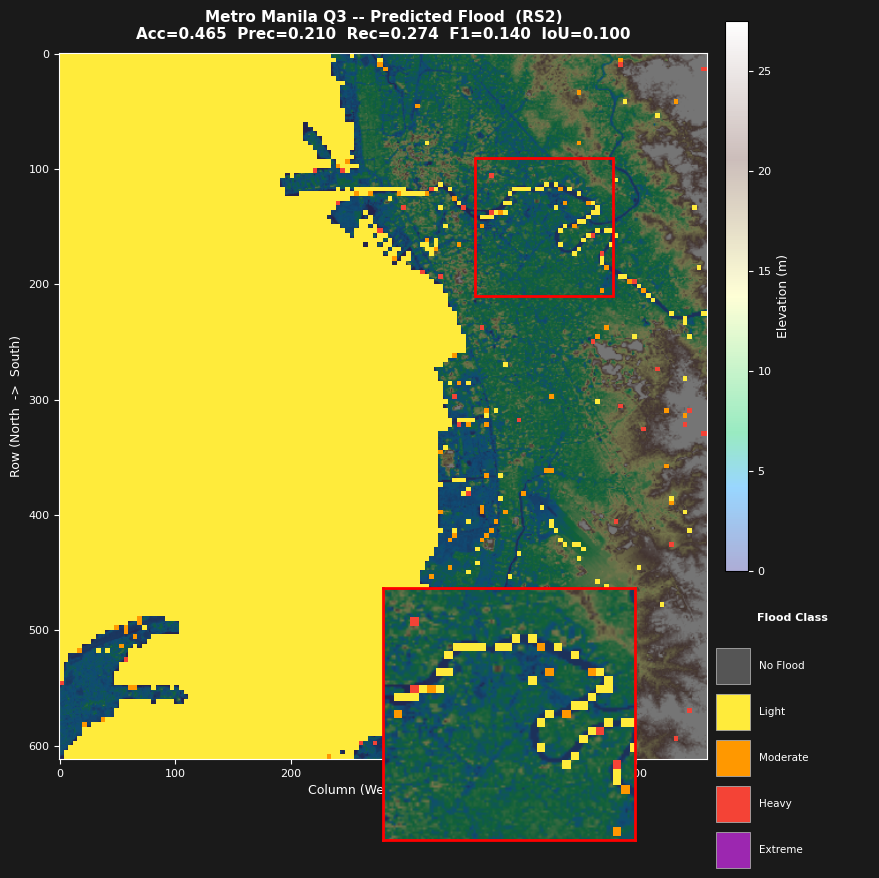

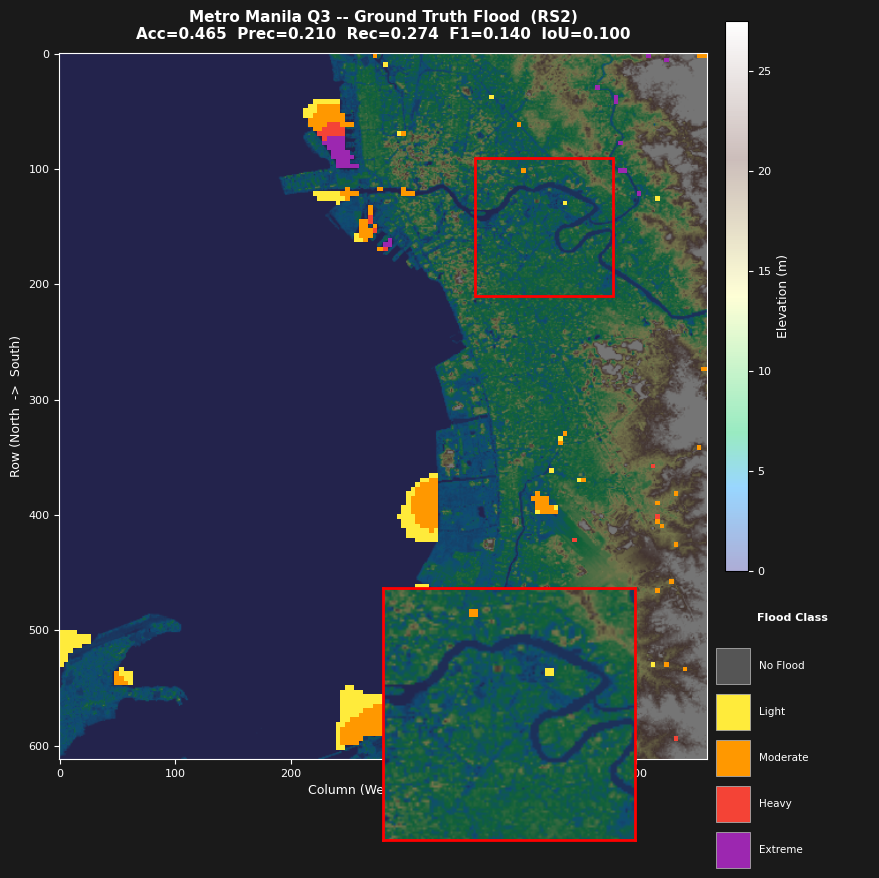

In [37]:
fig6 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig6.savefig("eval_dem_worst_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig7 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig7.savefig("eval_dem_worst_gt.png", dpi=150, bbox_inches='tight')

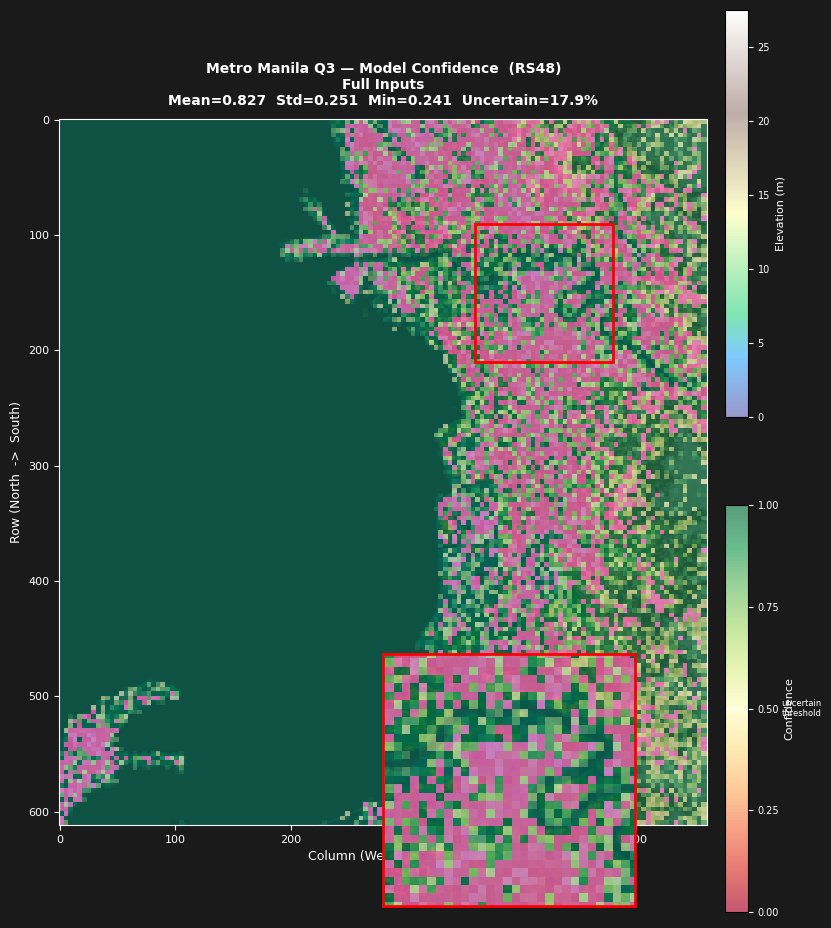

In [38]:
from testing import plot_confidence_on_dem

best_idx  = results['aggregate']['best_scenario']  - 1

fig_conf = plot_confidence_on_dem(
    dem_q3       = dem_q3,
    conf_map     = results['conf_maps'][best_idx],
    scenario_id  = results['aggregate']['best_scenario'],
    config_label = 'Full Inputs',
    confs_flat   = results['per_scenario'][best_idx]['confs_flat'],
    inset_center = (150, 420),
    figsize      = (9, 11),
    inset_size   = 60,
)
fig_conf.savefig("eval_dem_best_confidence.png", dpi=150, bbox_inches='tight')
plt.show()

# Web Config

Extracting full spatial patches...
  Spatial patches extracted: 85,986  shape: (85986, 4, 4, 3)
  Shape: (85986, 4, 4, 3)  (85986 patches, 4×4 pixels, 3 channels)

FLOOD INFERENCE ENGINE READY
  Device         : cuda
  Model          : ViT
  Spatial patches: 85,986
  Patch shape    : (4, 4, 3)
  Rain range     : [0.0000, 189.8531]
  Num classes    : 5
  Batch size     : 256


Test 1/4
Predicting 85,986 patches (batch_size=256)...
  ✓ 1,280/85,986 patches
  ✓ 2,560/85,986 patches
  ✓ 3,840/85,986 patches
  ✓ 5,120/85,986 patches
  ✓ 6,400/85,986 patches
  ✓ 7,680/85,986 patches
  ✓ 8,960/85,986 patches
  ✓ 10,240/85,986 patches
  ✓ 11,520/85,986 patches
  ✓ 12,800/85,986 patches
  ✓ 14,080/85,986 patches
  ✓ 15,360/85,986 patches
  ✓ 16,640/85,986 patches
  ✓ 17,920/85,986 patches
  ✓ 19,200/85,986 patches
  ✓ 20,480/85,986 patches
  ✓ 21,760/85,986 patches
  ✓ 23,040/85,986 patches
  ✓ 24,320/85,986 patches
  ✓ 25,600/85,986 patches
  ✓ 26,880/85,986 patches
  ✓ 28,160/85,986 patches
 

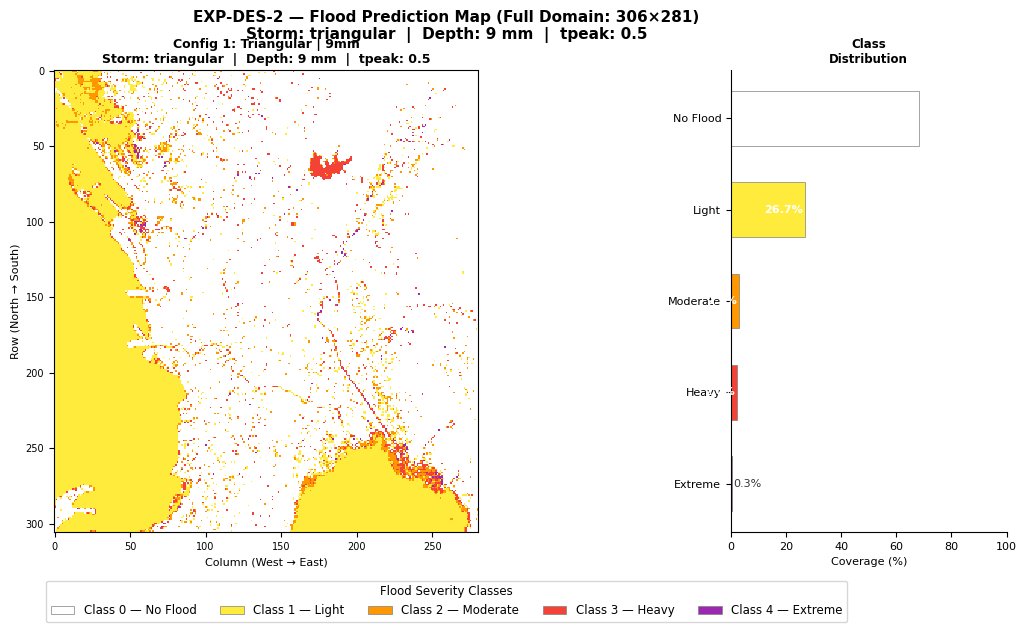

  ✓ Flood map saved  → checkpoints\web_config1_flood_map.png


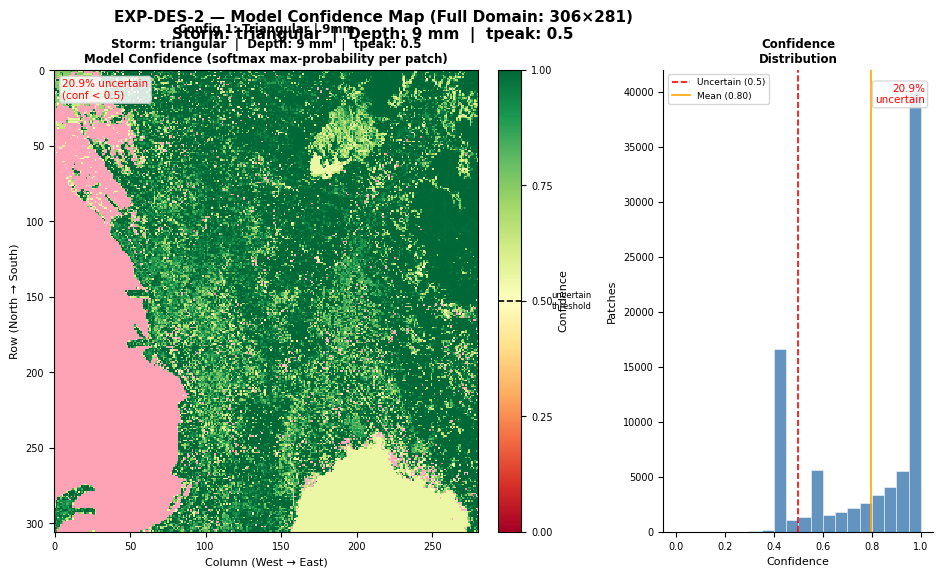

  ✓ Confidence map saved → checkpoints\web_config1_confidence_map.png
  ✓ GeoTIFF saved → checkpoints\web_config1_result.tif

Config 2: Front-Loaded | 9mm: SUCCESS
  No Flood: 69.6%
  Light: 26.9%
  Moderate: 2.2%
  Heavy: 1.0%
  Extreme: 0.3%


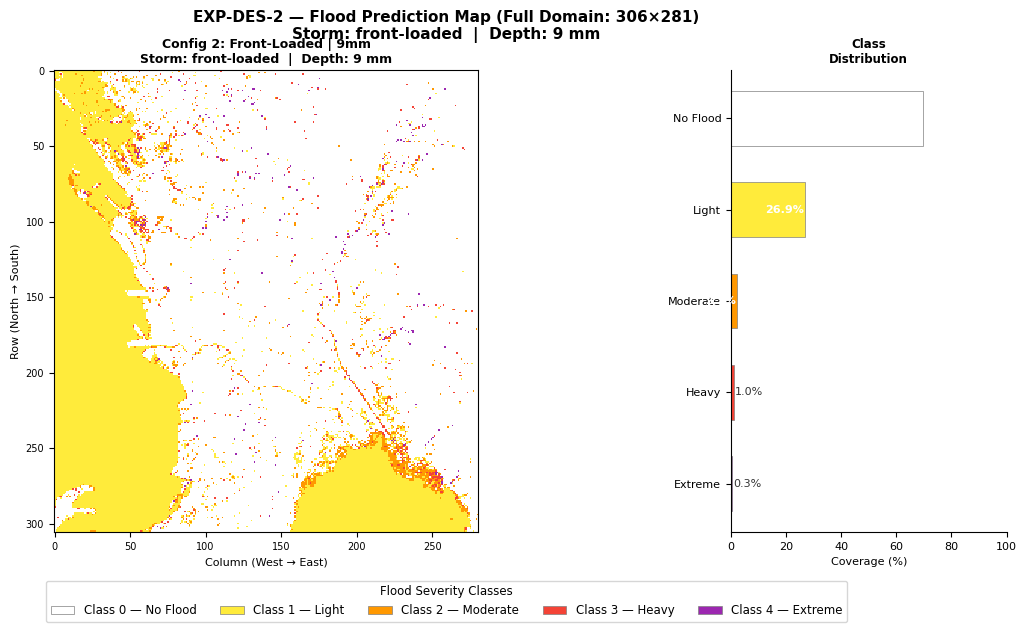

  ✓ Flood map saved  → checkpoints\web_config2_flood_map.png


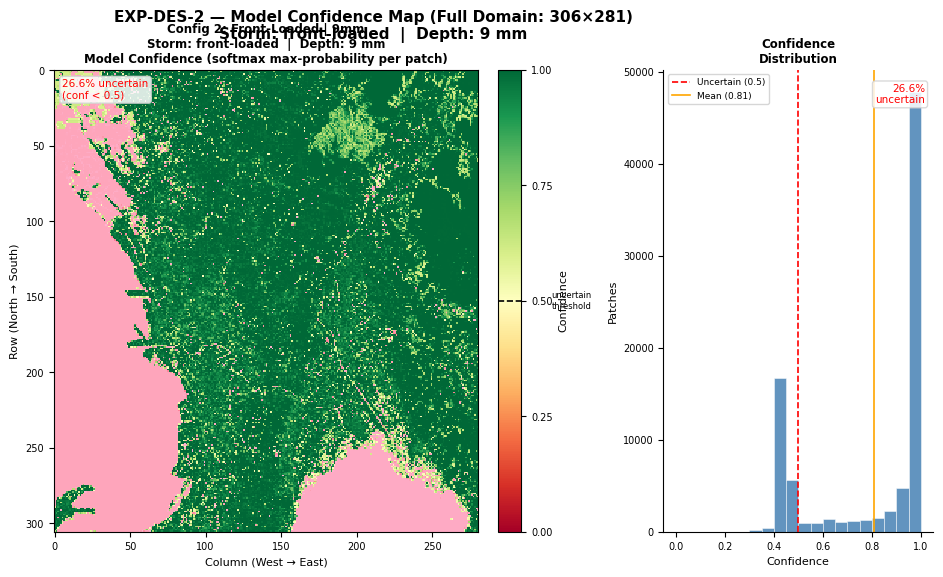

  ✓ Confidence map saved → checkpoints\web_config2_confidence_map.png
  ✓ GeoTIFF saved → checkpoints\web_config2_result.tif

Config 3: Back-Loaded | 10mm: SUCCESS
  No Flood: 67.7%
  Light: 26.5%
  Moderate: 2.7%
  Heavy: 2.5%
  Extreme: 0.6%


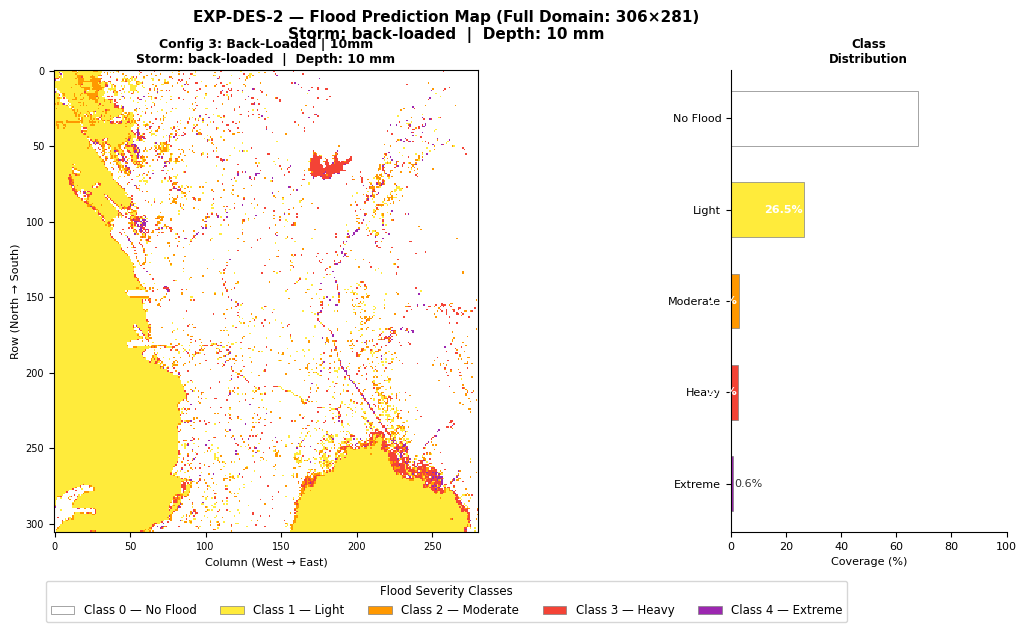

  ✓ Flood map saved  → checkpoints\web_config3_flood_map.png


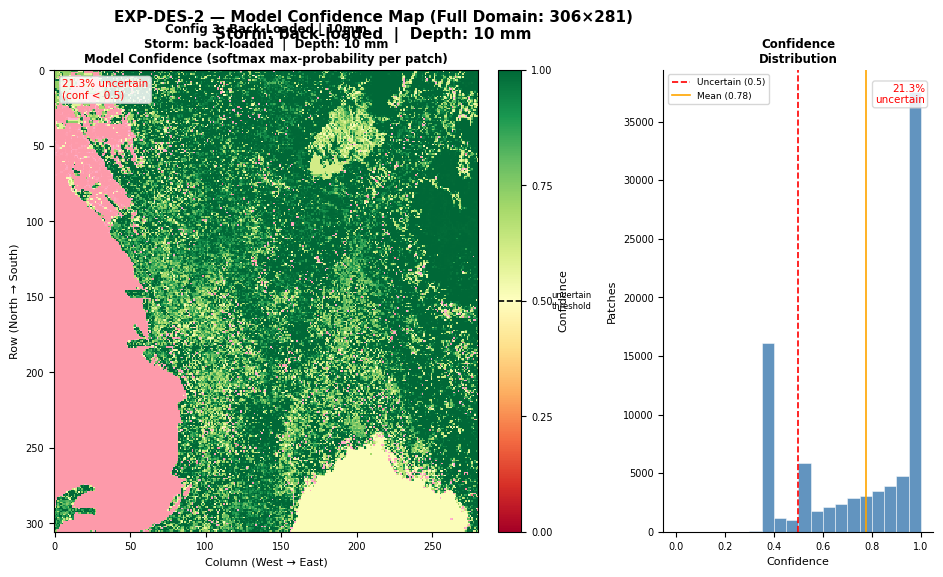

  ✓ Confidence map saved → checkpoints\web_config3_confidence_map.png
  ✓ GeoTIFF saved → checkpoints\web_config3_result.tif

Config 4: Balanced | 40mm: SUCCESS
  No Flood: 64.4%
  Light: 1.3%
  Moderate: 6.9%
  Heavy: 1.9%
  Extreme: 25.5%


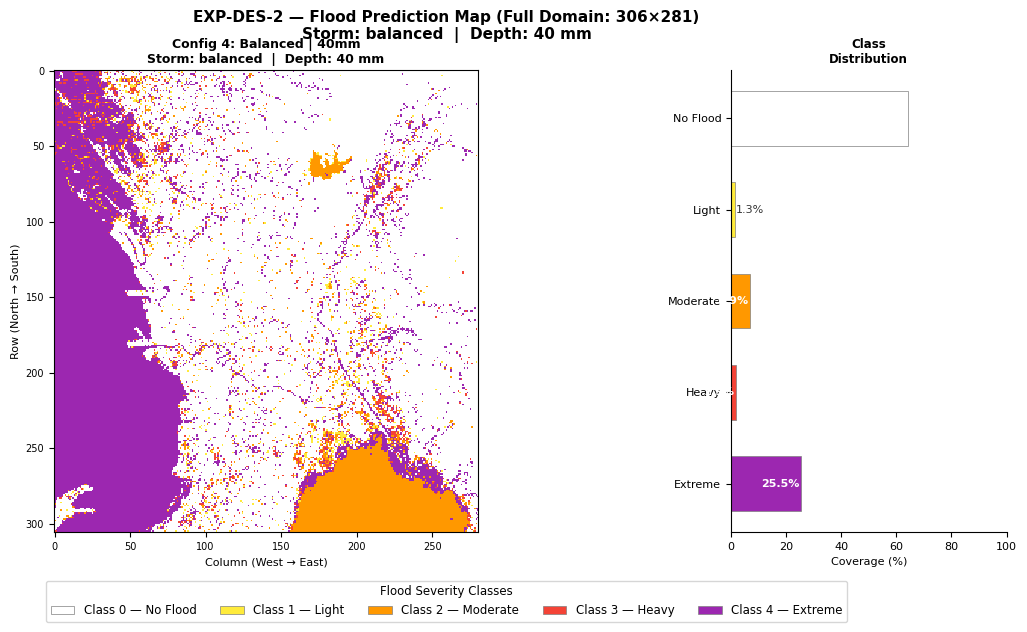

  ✓ Flood map saved  → checkpoints\web_config4_flood_map.png


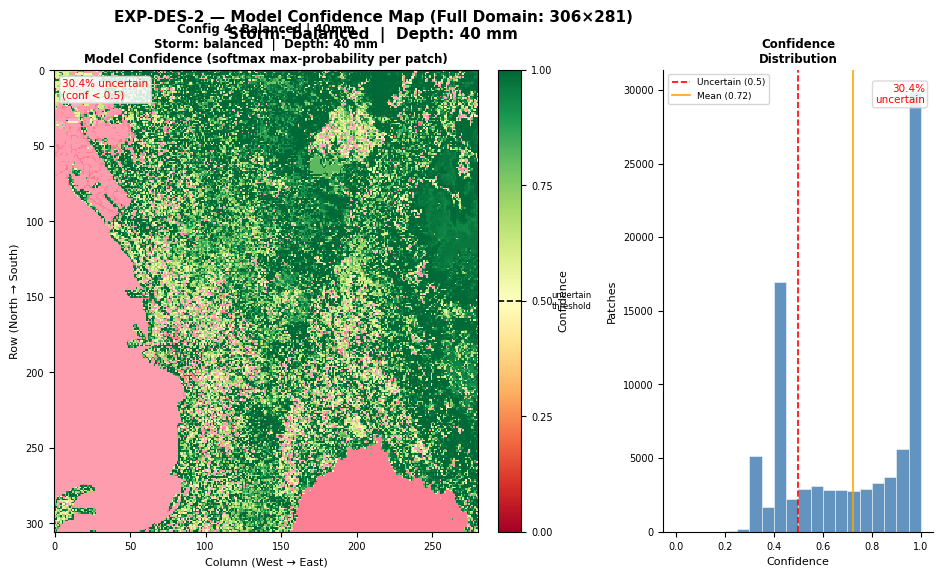

  ✓ Confidence map saved → checkpoints\web_config4_confidence_map.png
  ✓ GeoTIFF saved → checkpoints\web_config4_result.tif

✓ All web configurations processed (full spatial domain).


In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from inference import FloodInference

# ── Visualization Setup ───────────────────────────────────────────────────────
FLOOD_COLORS = {0: '#FFFFFF', 1: '#FFEB3B', 2: '#FF9800', 3: '#F44336', 4: '#9C27B0'}
FLOOD_LABELS = {0: 'No Flood', 1: 'Light', 2: 'Moderate', 3: 'Heavy', 4: 'Extreme'}

flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)
conf_cmap = 'RdYlGn'

legend_patches = [
    mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray', linewidth=0.5,
                   label=f'Class {i} — {FLOOD_LABELS[i]}')
    for i in range(5)
]

# ── Extract Full Spatial Patches ──────────────────────────────────────────────
print("Extracting full spatial patches...")
X_full = extract_spatial_patches(spatial_stack, patch_size=4)
print(f"  Shape: {X_full.shape}  (85986 patches, 4×4 pixels, 3 channels)")

# ── Initialize Inference Engine ───────────────────────────────────────────────
engine = FloodInference(
    model=model,
    device=device,
    rain_min=rain_min,
    rain_max=rain_max,
    X_spatial=X_full,       
    num_classes=cfg.train.num_classes,         
    batch_size=cfg.train.batch_size,
)

# ── Test Configurations ───────────────────────────────────────────────────────
test_configs = [
    {'storm_type': 'triangular', 'depth_mm': 9, 'tpeak': 0.5},
    {'storm_type': 'front-loaded', 'depth_mm': 9, 'tpeak': None},
    {'storm_type': 'back-loaded', 'depth_mm': 10, 'tpeak': None},
    {'storm_type': 'balanced', 'depth_mm': 40, 'tpeak': None},
]

# ── Run Batch Predictions ─────────────────────────────────────────────────────
# Pass n_h and n_w to predict_batch() to get 2D map reconstruction
results = engine.predict_batch(
    test_configs,
    n_h=306,   # Full domain: 306 rows
    n_w=281,   # Full domain: 281 columns
)

# ── Helper Functions ──────────────────────────────────────────────────────────

def build_subtitle(cfg: dict) -> str:
    """Build informative subtitle."""
    parts = [f"Storm: {cfg['storm_type']}", f"Depth: {cfg['depth_mm']} mm"]
    if cfg.get('tpeak') is not None:
        parts.append(f"tpeak: {cfg['tpeak']}")
    return '  |  '.join(parts)


def add_warning_banner(ax, warnings):
    """Add warning banner if validation warnings exist."""
    if warnings:
        ax.text(
            0.5, 0.02,
            f'⚠ {len(warnings)} warning(s) — inputs outside training range',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=7.5, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#B8860B',
                      edgecolor='none', alpha=0.88),
        )


def compute_class_pcts(flood_map):
    """Compute percentage of each flood class."""
    total = flood_map.size
    return {i: 100 * (flood_map == i).sum() / total for i in range(5)}


def save_result_as_tif(
    flood_map: np.ndarray,
    conf_map: np.ndarray,
    config: dict,
    save_path: str,
    transform=None,
    crs=None,
) -> None:
    """Save prediction as GeoTIFF with metadata."""
    H, W = flood_map.shape
    
    with rasterio.open(
        save_path,
        mode='w',
        driver='GTiff',
        height=H,
        width=W,
        count=2,
        dtype='float32',
        crs=crs,
        transform=transform,
        compress='lzw',
    ) as dst:
        dst.write(flood_map.astype(np.float32), 1)
        dst.write(conf_map.astype(np.float32), 2)
        dst.update_tags(1, description='Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)')
        dst.update_tags(2, description='Model Confidence (softmax max-probability per patch 0.0-1.0)')
        dst.update_tags(
            model='EXP-DES-2 ViTFloodClassifier',
            domain='Full spatial domain (306×281 patches)',
            storm_type=config['storm_type'],
            depth_mm=str(config['depth_mm']),
            tpeak=str(config.get('tpeak')),
        )
    print(f"  ✓ GeoTIFF saved → {save_path}")


# ── Process Each Result ───────────────────────────────────────────────────────

for i, (result, config) in enumerate(zip(results, test_configs)):
    cfg_label = f"Config {i+1}: {config['storm_type'].title()} | {config['depth_mm']}mm"
    
    # ── Check for errors ──────────────────────────────────────────────────────
    if 'error' in result:
        print(f"\n{cfg_label}: ERROR — {result['error']}")
        continue
    
    # ── Extract data from result ──────────────────────────────────────────────
    print(f"\n{cfg_label}: SUCCESS")
    for cls, stat in result['statistics'].items():
        print(f"  {cls}: {stat['percentage']:.1f}%")
    
    flood_map = result['flood_map'].astype(np.float32)  # (306, 281)
    conf_map = result['conf_map'].astype(np.float32)    # (306, 281)
    patch_confs = result['patch_confidences']           # (85986,)
    warnings = result.get('warnings', [])
    pcts = compute_class_pcts(flood_map)
    frac_low = (patch_confs < 0.5).mean() * 100
    subtitle = build_subtitle(config)
    
    # ── FIGURE 1: Flood Prediction Map ────────────────────────────────────────
    fig1, axes1 = plt.subplots(
        1, 2, figsize=(14, 6),
        gridspec_kw={'width_ratios': [2.5, 1], 'wspace': 0.25}
    )
    ax_flood, ax_bar = axes1
    
    # Plot flood map
    ax_flood.imshow(flood_map, cmap=flood_cmap, norm=flood_norm,
                    interpolation='nearest', origin='upper')
    ax_flood.set_title(f'{cfg_label}\n{subtitle}',
                       fontsize=9, fontweight='bold', pad=5)
    ax_flood.set_xlabel('Column (West → East)', fontsize=8)
    ax_flood.set_ylabel('Row (North → South)', fontsize=8)
    ax_flood.tick_params(labelsize=7)
    add_warning_banner(ax_flood, warnings)
    
    # Class distribution bar chart
    labels = [FLOOD_LABELS[j] for j in range(5)]
    values = [pcts[j] for j in range(5)]
    colors = [FLOOD_COLORS[j] for j in range(5)]
    bars = ax_bar.barh(labels, values, color=colors,
                       edgecolor='gray', linewidth=0.5, height=0.6)
    
    # Add percentage labels on bars
    for bar, val in zip(bars, values):
        if val > 1.5:
            ax_bar.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', ha='right',
                        fontsize=8, color='white', fontweight='bold')
        elif val > 0.1:
            ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', ha='left',
                        fontsize=8, color='#333333')
    
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel('Coverage (%)', fontsize=8)
    ax_bar.set_title('Class\nDistribution', fontsize=8.5, fontweight='bold', pad=5)
    ax_bar.tick_params(axis='both', labelsize=8)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.invert_yaxis()
    
    fig1.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=8.5,
                frameon=True, title='Flood Severity Classes', title_fontsize=8.5,
                bbox_to_anchor=(0.5, -0.05))
    fig1.suptitle(f'EXP-DES-2 — Flood Prediction Map (Full Domain: 306×281)\n{subtitle}',
                  fontsize=11, fontweight='bold', y=0.98)
    
    save_flood = str(cfg.train.output_dir / f'web_config{i+1}_flood_map.png')
    plt.savefig(save_flood, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  ✓ Flood map saved  → {save_flood}")
    
    # ── FIGURE 2: Confidence Map ──────────────────────────────────────────────
    fig2, axes2 = plt.subplots(
        1, 2, figsize=(14, 6),
        gridspec_kw={'width_ratios': [2.5, 1], 'wspace': 0.30},
    )
    ax_conf, ax_hist = axes2
    
    # Plot confidence map
    im = ax_conf.imshow(conf_map, cmap=conf_cmap, vmin=0.0, vmax=1.0,
                        interpolation='nearest', origin='upper')
    ax_conf.set_title(
        f'{cfg_label}\n{subtitle}\nModel Confidence (softmax max-probability per patch)',
        fontsize=8.5, fontweight='bold', pad=5,
    )
    ax_conf.set_xlabel('Column (West → East)', fontsize=8)
    ax_conf.set_ylabel('Row (North → South)', fontsize=8)
    ax_conf.tick_params(labelsize=7)
    add_warning_banner(ax_conf, warnings)
    
    # Colorbar
    cbar = fig2.colorbar(im, ax=ax_conf, fraction=0.035, pad=0.03)
    cbar.set_label('Confidence', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
    cbar.ax.axhline(y=0.5, color='black', linewidth=1.2, linestyle='--')
    cbar.ax.text(2.3, 0.5, 'uncertain\nthreshold', fontsize=6, va='center',
                 color='black')
    
    # Overlay uncertain regions
    uncertain_overlay = conf_map.copy().astype(float)
    uncertain_overlay[conf_map >= 0.5] = np.nan
    uncertain_overlay[conf_map < 0.5] = 1.0
    ax_conf.imshow(uncertain_overlay, cmap='cool', alpha=0.30,
                   vmin=0, vmax=1, interpolation='nearest', origin='upper')
    
    # Uncertainty stats on map
    ax_conf.text(
        0.02, 0.98, f'{frac_low:.1f}% uncertain\n(conf < 0.5)',
        transform=ax_conf.transAxes, ha='left', va='top', fontsize=7.5,
        color='red' if frac_low > 20 else 'gray',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='lightgray', alpha=0.85),
    )
    
    # Confidence histogram
    ax_hist.hist(patch_confs, bins=20, range=(0, 1),
                 color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax_hist.axvline(x=0.5, color='red', linewidth=1.2, linestyle='--',
                    label='Uncertain (0.5)')
    ax_hist.axvline(x=patch_confs.mean(), color='orange', linewidth=1.2,
                    linestyle='-', label=f"Mean ({patch_confs.mean():.2f})")
    ax_hist.set_xlabel('Confidence', fontsize=8)
    ax_hist.set_ylabel('Patches', fontsize=8)
    ax_hist.set_title('Confidence\nDistribution', fontsize=8.5, fontweight='bold', pad=5)
    ax_hist.tick_params(labelsize=7)
    ax_hist.legend(fontsize=6.5, loc='upper left')
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(
        0.97, 0.97, f'{frac_low:.1f}%\nuncertain',
        transform=ax_hist.transAxes, ha='right', va='top', fontsize=7.5,
        color='red' if frac_low > 20 else 'gray',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor='lightgray', alpha=0.85),
    )
    
    fig2.suptitle(f'EXP-DES-2 — Model Confidence Map (Full Domain: 306×281)\n{subtitle}',
                  fontsize=11, fontweight='bold', y=0.98)
    
    save_conf = str(cfg.train.output_dir / f'web_config{i+1}_confidence_map.png')
    plt.savefig(save_conf, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  ✓ Confidence map saved → {save_conf}")
    
    # ── GeoTIFF Export ────────────────────────────────────────────────────────
    try:
        with rasterio.open(dem_path) as src:
            dem_meta = src.meta
        save_result_as_tif(
            flood_map=flood_map,
            conf_map=conf_map,
            config=config,
            save_path=str(cfg.train.output_dir / f'web_config{i+1}_result.tif'),
            transform=dem_meta['transform'],
            crs=dem_meta['crs'],
        )
    except Exception as e:
        print(f"  ℹ Skipped GeoTIFF export: {e}")

print("\n✓ All web configurations processed (full spatial domain).")